# 02. Alpha diversity and PCA

This notebook makes exploratory plots for a one-bioproject workshop dataset:

1. alpha diversity by clinical group;
2. CLR-PCA by clinical group.

Between-bioproject batch-effect analysis is intentionally absent: with one bioproject it is not identifiable.

In [1]:
from pathlib import Path

# Main paths. Usually only this cell needs editing.
PROJECT_DIR = Path(".").resolve()
DATA_DIR = PROJECT_DIR / "data"
OUT_DIR = PROJECT_DIR / "outputs_minimal"

TAX_PATH = DATA_DIR / "tax.csv"
PATHWAY_PATH = DATA_DIR / "path.csv"
METADATA_PATH = DATA_DIR / "metadata.csv"

FIG_DIR = OUT_DIR / "figures"
RESULTS_DIR = OUT_DIR / "results"

FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("TAX:", TAX_PATH)
print("PATH:", PATHWAY_PATH)
print("METADATA:", METADATA_PATH)
print("OUT:", OUT_DIR)

TAX: /srv/common/seraph/workshop/code/data/tax.csv
PATH: /srv/common/seraph/workshop/code/data/path.csv
METADATA: /srv/common/seraph/workshop/code/data/metadata.csv
OUT: /srv/common/seraph/workshop/code/outputs_minimal


In [2]:
import matplotlib.pyplot as plt

from simple_utils import GROUP_ORDER, alpha_diversity_table, load_data, pca_scores_from_clr

In [3]:
# Main switch.
# Use "TAX" for taxonomic profiles or "PATH" for pathway profiles.
FEATURE_SET = "TAX"

bundle = load_data(TAX_PATH, PATHWAY_PATH, METADATA_PATH)
X = bundle.tax if FEATURE_SET == "TAX" else bundle.path
meta = bundle.meta.loc[X.index].copy()

meta = meta[meta["group"] != "Unknown"].copy()
X = X.loc[meta.index]

print("Feature set:", FEATURE_SET)
print("Samples:", len(meta))
print("Features:", X.shape[1])
print("Bioprojects:", meta["bioproject"].nunique())

Feature set: TAX
Samples: 193
Features: 719
Bioprojects: 1


In [4]:
alpha = alpha_diversity_table(X)
plot_df = meta[["group", "bioproject"]].join(alpha)
plot_df.to_csv(RESULTS_DIR / f"alpha_diversity_{FEATURE_SET}.csv")
plot_df.head()

,group,bioproject,observed_features,shannon,simpson
run,,,,,
SRR27355121,Caries (K02),PRJNA1057503,256,3.241305,0.896545
SRR27355123,K02+K05,PRJNA1057503,169,3.374398,0.937301
SRR27355124,Periodontitis (K05),PRJNA1057503,125,2.875020,0.900697
SRR27355125,Periodontitis (K05),PRJNA1057503,186,3.674578,0.953311
SRR27355152,Periodontitis (K05),PRJNA1057503,146,3.651373,0.961772


/tmp/ipykernel_673975/1482544270.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)


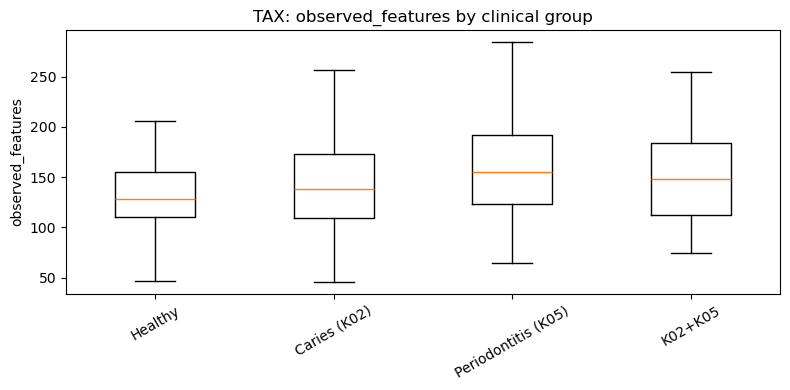

/tmp/ipykernel_673975/1482544270.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)


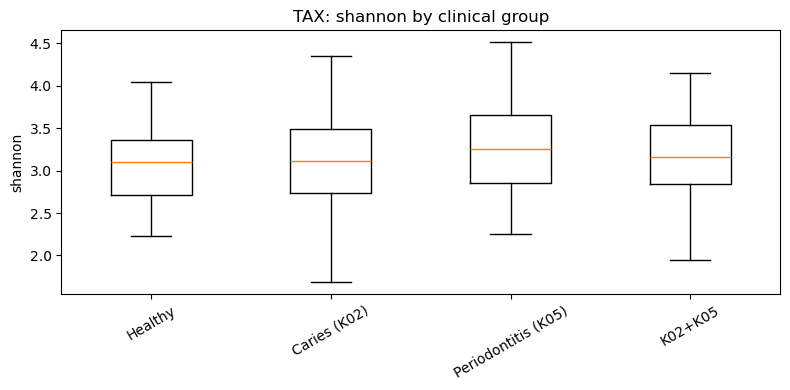

/tmp/ipykernel_673975/1482544270.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)


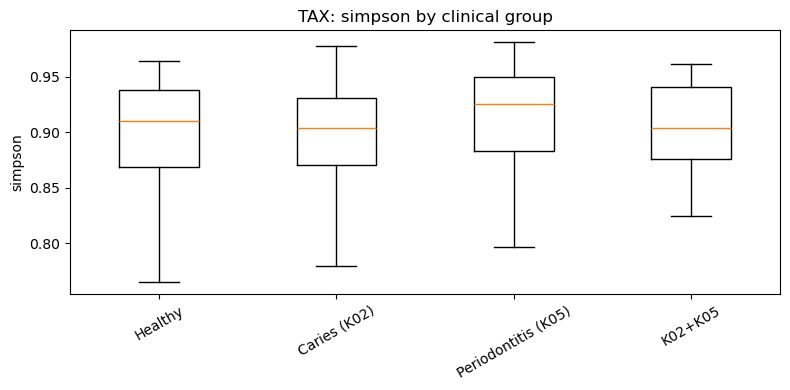

In [5]:
for metric in ["observed_features", "shannon", "simpson"]:
    labels = [g for g in GROUP_ORDER if (plot_df["group"] == g).any()]
    data = [plot_df.loc[plot_df["group"] == g, metric].dropna() for g in labels]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.boxplot(data, labels=labels, showfliers=False)
    ax.set_title(f"{FEATURE_SET}: {metric} by clinical group")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{FEATURE_SET}_alpha_{metric}_by_group.png", dpi=200)
    plt.show()

In [6]:
scores, explained = pca_scores_from_clr(X)
ordination = meta[["group", "bioproject"]].join(scores)
ordination.to_csv(RESULTS_DIR / f"ordination_{FEATURE_SET}.csv")

print("Explained variance:", explained)
ordination.head()

Explained variance: [0.11869624 0.08631512]


,group,bioproject,PC1,PC2
run,,,,
SRR27355121,Caries (K02),PRJNA1057503,7.970908,-14.592527
SRR27355123,K02+K05,PRJNA1057503,-3.004640,-6.884164
SRR27355124,Periodontitis (K05),PRJNA1057503,-15.126637,18.509479
SRR27355125,Periodontitis (K05),PRJNA1057503,-0.185728,-16.989724
SRR27355152,Periodontitis (K05),PRJNA1057503,22.455101,13.389009


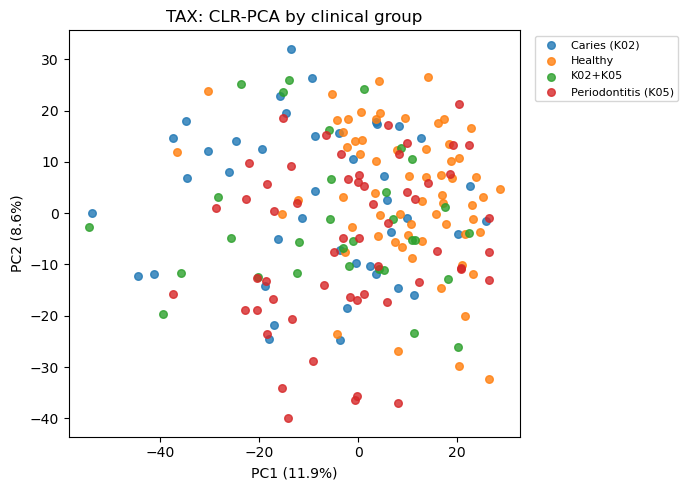

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))

for group, part in ordination.groupby("group"):
    ax.scatter(part["PC1"], part["PC2"], s=30, alpha=0.8, label=group)

ax.set_xlabel(f"PC1 ({explained[0] * 100:.1f}%)")
ax.set_ylabel(f"PC2 ({explained[1] * 100:.1f}%)")
ax.set_title(f"{FEATURE_SET}: CLR-PCA by clinical group")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / f"{FEATURE_SET}_pca_by_group.png", dpi=200)
plt.show()